In [1]:
import pandas as pd
import matplotlib.pyplot as plt


chemin = "./data/raw/comptages.csv"
df = pd.read_csv(chemin, sep=";")
df.head()

,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,1960,Av_de_l'Opera,2026-08-31T23:00:00+00:00,156.0,1.74667,Fluide,2139,Pl_de_l'Opera,211,Av_de_l'Opera-Antin-Augustin,Ouvert
1,57,St_Jacques,2026-08-31T23:00:00+00:00,206.0,3.22778,Fluide,52,St_Jacques-Galande,53,Bd_St_Germain-St_Jacques,Ouvert
2,298,Av_de_l'Opera,2026-08-31T23:00:00+00:00,257.0,1.73667,Fluide,178,Av_de_l'Opera-Echelle,87,Pl_Andre_Malraux,Ouvert
3,300,Av_de_l'Opera,2026-08-31T23:00:00+00:00,158.0,2.21722,Fluide,177,Av_de_l'Opera-Pyramides,178,Av_de_l'Opera-Echelle,Ouvert
4,367,Av_de_l'Opera,2026-08-31T23:00:00+00:00,156.0,1.44167,Fluide,211,Av_de_l'Opera-Antin-Augustin,179,Av_de_l'Opera-Petits_Champs,Ouvert


In [2]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144012 entries, 0 to 144011
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   iu_ac             144012 non-null  int64  
 1   libelle           144012 non-null  str    
 2   t_1h              144012 non-null  str    
 3   q                 118464 non-null  float64
 4   k                 115069 non-null  float64
 5   etat_trafic       144012 non-null  str    
 6   iu_nd_amont       144012 non-null  int64  
 7   libelle_nd_amont  144012 non-null  str    
 8   iu_nd_aval        144012 non-null  int64  
 9   libelle_nd_aval   144012 non-null  str    
 10  etat_barre        144012 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 12.1 MB


In [3]:
df.describe()

,iu_ac,q,k,iu_nd_amont,iu_nd_aval
count,144012.000000,118464.000000,115069.000000,144012.000000,144012.000000
mean,2623.424242,287.287589,5.325570,1337.060606,1346.666667
std,2288.470404,205.428998,6.703946,1207.696431,1199.249549
min,57.000000,0.000000,0.000000,52.000000,53.000000
25%,366.000000,113.000000,1.309450,179.000000,179.000000
50%,1960.000000,260.000000,3.287220,358.000000,359.000000
75%,5092.000000,426.000000,6.225000,2685.000000,2685.000000
max,5107.000000,5473.950000,78.702220,2690.000000,2690.000000


In [4]:
print(f"Lignes : {df.shape[0]:,}")
print(f"Colonnes : {df.shape[1]}")

Lignes : 144,012
Colonnes : 11


In [5]:
pd.DataFrame({
    "type": df.dtypes,
    "nb_distincts": df.nunique(),
    "exemple": df.iloc[0],
})

,type,nb_distincts,exemple
iu_ac,int64,33,1960
libelle,str,3,Av_de_l'Opera
t_1h,str,4364,2026-08-31T23:00:00+00:00
q,float64,1666,156.0
k,float64,31279,1.74667
etat_trafic,str,5,Fluide
iu_nd_amont,int64,23,2139
libelle_nd_amont,str,23,Pl_de_l'Opera
iu_nd_aval,int64,23,211
libelle_nd_aval,str,23,Av_de_l'Opera-Antin-Augustin


In [6]:
manquants = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "part_%": (df.isna().mean() * 100).round(2),
})

manquants.sort_values("part_%", ascending=False)

,nb_manquants,part_%
k,28943,20.10
q,25548,17.74
iu_ac,0,0.00
libelle,0,0.00
t_1h,0,0.00
etat_trafic,0,0.00
iu_nd_amont,0,0.00
libelle_nd_amont,0,0.00
iu_nd_aval,0,0.00
libelle_nd_aval,0,0.00


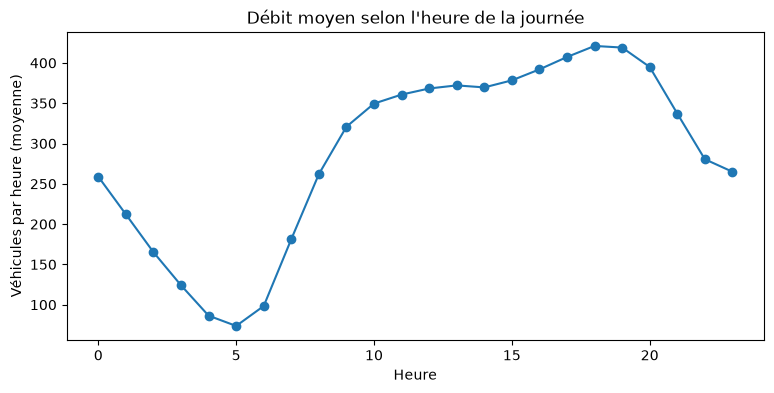

In [7]:
df["t_1h"] = pd.to_datetime(df["t_1h"])

df["heure"] = df["t_1h"].dt.tz_convert("Europe/Paris").dt.hour 
profil = df.groupby("heure")["q"].mean()

profil.plot(kind="line", marker="o", figsize=(9, 4))
plt.title("Débit moyen selon l'heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Véhicules par heure (moyenne)")
plt.show()

Le débit moyen suit un rythme journalier il atteint son minimum vers 5h du matin (environ 75 véhicule/heure), augmente fortement entre 6h et 9h, se stabilise en journée autour de 380 véhicule par heure, puis culmine en fin d'après-midi, vers 18h-19h, à environ 455 véh/h, avant de redescendre le soir. Cela confirme que les faibles débits de l'histogramme correspondent surtout aux heures de nuit.

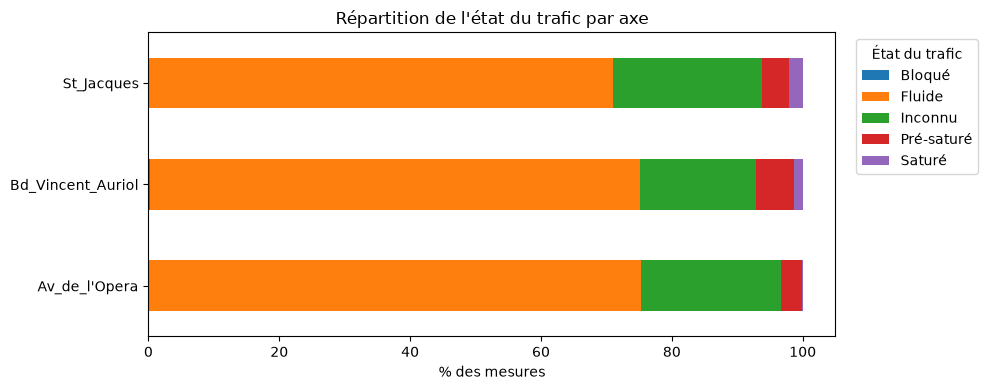

In [8]:
repartition = (
    pd.crosstab(df["libelle"], df["etat_trafic"], normalize="index") * 100
)

repartition.plot(kind="barh", stacked=True, figsize=(10, 4))
plt.title("Répartition de l'état du trafic par axe")
plt.xlabel("% des mesures")
plt.ylabel("")
plt.legend(title="État du trafic", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Sur les trois axes, la circulation est fluide dans environ trois quarts des mesures. Les états de congestion (pré-saturé et saturé) restent minoritaires, avec l'avenue de l'Opéra apparaissant comme la plus fluide. Une part notable des mesures a peu pres 20 % est classée « Inconnu », ce qui limite la comparaison.